In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix, lil_matrix
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
import pyreadr 
from pathlib import Path
import os

os.chdir(Path.cwd().parent)

In [ ]:
# ================================================================
# Imports
# ================================================================
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix, coo_matrix, diags, bmat
from scipy.sparse.csgraph import connected_components
from sksparse.cholmod import cholesky
from polyagamma import random_polyagamma
import geopandas as gpd
import pyreadr
import pickle
from IPython.display import clear_output, display

# ================================================================
# Load data (remove isolated points)
# ================================================================
no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

snow = pyreadr.read_r("snow_cleaned_full.Rda")
snow = list(snow.values())[0]

all_y = snow.drop(index=no_nbs).reset_index(drop=True)
coords_full = all_y.iloc[:, :2].to_numpy()
y_full      = all_y.iloc[:, 2:].to_numpy()

S_full, TT = y_full.shape
period = 52

# ================================================================
# Global time trend (scaled once)
# ================================================================
t_full = np.arange(1, TT + 1)
t_trend_full = (t_full - t_full.mean()) / t_full.std(ddof=0)

# ================================================================
# Build adjacency on FULL graph
# ================================================================
gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_full[:, 0], coords_full[:, 1]),
    crs="EPSG:4326"
)
gdf = gdf.to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")
xy_full = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6

A_full = (squareform(pdist(xy_full)) <= 0.22).astype(int)
np.fill_diagonal(A_full, 0)
A_full = csr_matrix(A_full)

# ================================================================
# Merge two largest connected components
# ================================================================
n_comp, labels = connected_components(A_full, directed=False)
sizes = np.bincount(labels)
comp1, comp2 = np.argsort(sizes)[-2:][::-1]

keep = np.where((labels == comp1) | (labels == comp2))[0]

coords = coords_full[keep]
xy     = xy_full[keep]
y      = y_full[keep]
S      = y.shape[0]

# ================================================================
# Rebuild adjacency (merged)
# ================================================================
A = (squareform(pdist(xy)) <= 0.22).astype(int)
np.fill_diagonal(A, 0)
A = csr_matrix(A)

deg = np.array(A.sum(axis=1)).flatten()
Q_icar = diags(deg) - A
I_S    = diags(np.ones(S))

# ================================================================
# USER-DEFINED WEEK SPLITS
# ================================================================
bin_edges = np.array([0, 13, 26, 39, 52])
time_bin = len(bin_edges) - 1
bin_str = "_".join(str(x) for x in bin_edges)

# ================================================================
# Helpers
# ================================================================
def week_block_indices(w, K, time_bin, S):
    idx = np.empty(K * S, dtype=int)
    p = 0
    for k in range(K):
        start = (k * time_bin + w) * S
        idx[p:p+S] = np.arange(start, start + S)
        p += S
    return idx

def theta_slice(k, w, time_bin, S):
    start = (k * time_bin + w) * S
    return slice(start, start + S)

# ================================================================
# ============================ p01 ================================
# ================================================================
event = "p01"

loc_mask = (y[:, :-1] == 0)
row_idx, time_idx = np.where(loc_mask)
N = len(row_idx)

outcome = y[row_idx, time_idx + 1]
kappa = outcome - 0.5

t_raw   = time_idx + 1
t_trend = t_trend_full[time_idx]

# >>> FIX: map to week-of-year <<<
week_in_year = ((t_raw - 1) % 52) + 1
week_raw = np.zeros_like(week_in_year, dtype=int)

for b in range(1, len(bin_edges)):
    week_raw[week_in_year > bin_edges[b]] = b

# safety (theoretical no-op, but guarantees no overflow)
week_raw[week_raw >= time_bin] = time_bin - 1

cov = np.column_stack([
    np.ones(N), np.ones(N),
    np.cos(2*np.pi*week_in_year/period),
    np.cos(2*np.pi*week_in_year/period),
    np.sin(2*np.pi*week_in_year/period),
    np.sin(2*np.pi*week_in_year/period),
    t_trend, t_trend
])
K = cov.shape[1]

rows, cols, vals = [], [], []
for i in tqdm(range(N), desc="Building X | p01", leave=False):
    s = row_idx[i]
    w = week_raw[i]
    for k in range(K):
        col = s + S * (w + time_bin * k)
        rows.append(i)
        cols.append(col)
        vals.append(cov[i, k])

X = coo_matrix((vals, (rows, cols)),
               shape=(N, K * time_bin * S)).tocsr()

burn, thin, tot_save = 1000, 5, 1000
total_iters = burn + tot_save * thin
a0, b0 = 1, 1

all_theta = np.zeros((K, time_bin, S, tot_save))
all_tau   = np.zeros((K, time_bin, tot_save))

Q_template = []
for k in range(K):
    Qk = Q_icar if (k % 2 == 0) else I_S
    for _ in range(time_bin):
        Q_template.append(Qk)

curr_theta = np.ones(K * time_bin * S)
curr_tau   = np.ones(K * time_bin) * 100
rhs = X.T @ kappa
save_idx = 0

for it in tqdm(range(total_iters), desc="MCMC | p01", leave=True):

    block_list = [curr_tau[j] * Q_template[j] for j in range(K*time_bin)]
    curr_prec = bmat(
        [[block_list[i] if i == j else None for j in range(K*time_bin)]
         for i in range(K*time_bin)],
        format="csr"
    )

    omega = random_polyagamma(1, X @ curr_theta)
    post_prec = X.T.multiply(omega) @ X + curr_prec

    for w in range(time_bin):
        idx = week_block_indices(w, K, time_bin, S)
        factor = cholesky(post_prec[np.ix_(idx, idx)])
        curr_theta[idx] = (
            factor.solve_A(rhs[idx]) +
            factor.solve_A(np.random.randn(len(idx)))
        )

    for k in range(K):
        for w in range(time_bin):
            j = k*time_bin + w
            beta = curr_theta[j*S:(j+1)*S]
            Qj = Q_icar if (k % 2 == 0) else I_S
            rk = (S-1) if (k % 2 == 0) else S
            quad = beta @ (Qj @ beta)
            curr_tau[j] = np.random.gamma(
                a0 + 0.5*rk, 1.0/(b0 + 0.5*quad)
            )
    tau_mat = curr_tau.reshape(K, time_bin)
    clear_output(wait=True)
    display(pd.DataFrame(tau_mat.T))
    
    if it >= burn and (it-burn) % thin == 0:
        for k in range(K):
            for w in range(time_bin):
                all_theta[k,w,:,save_idx] = curr_theta[theta_slice(k,w,time_bin,S)]
        all_tau[:,:,save_idx] = curr_tau.reshape(K,time_bin)
        save_idx += 1

        tau_mat = curr_tau.reshape(K, time_bin)
        clear_output(wait=True)
        display(pd.DataFrame(tau_mat.T))

        if save_idx == tot_save:
            break

with open(f"BYM_{bin_str}_p01.pkl", "wb") as f:
    pickle.dump({
        "keep_idx": keep,
        "theta": all_theta,
        "tau": all_tau,
        "bin_edges": bin_edges
    }, f)




In [6]:
# ================================================================
# Imports
# ================================================================
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix, coo_matrix, diags, bmat
from scipy.sparse.csgraph import connected_components
from sksparse.cholmod import cholesky
from polyagamma import random_polyagamma
import geopandas as gpd
import pyreadr
import pickle
from IPython.display import clear_output, display

# ================================================================
# Load data (remove isolated points)
# ================================================================
no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

snow = pyreadr.read_r("snow_cleaned_full.Rda")
snow = list(snow.values())[0]

all_y = snow.drop(index=no_nbs).reset_index(drop=True)
coords_full = all_y.iloc[:, :2].to_numpy()
y_full      = all_y.iloc[:, 2:].to_numpy()

S_full, TT = y_full.shape
period = 52

# ================================================================
# Global time trend (scaled once)
# ================================================================
t_full = np.arange(1, TT + 1)
t_trend_full = (t_full - t_full.mean()) / t_full.std(ddof=0)

# ================================================================
# Build adjacency on FULL graph
# ================================================================
gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_full[:, 0], coords_full[:, 1]),
    crs="EPSG:4326"
)
gdf = gdf.to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")
xy_full = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6

A_full = (squareform(pdist(xy_full)) <= 0.22).astype(int)
np.fill_diagonal(A_full, 0)
A_full = csr_matrix(A_full)

# ================================================================
# Merge two largest connected components
# ================================================================
n_comp, labels = connected_components(A_full, directed=False)
sizes = np.bincount(labels)
comp1, comp2 = np.argsort(sizes)[-2:][::-1]

keep = np.where((labels == comp1) | (labels == comp2))[0]

coords = coords_full[keep]
xy     = xy_full[keep]
y      = y_full[keep]
S      = y.shape[0]

# ================================================================
# Rebuild adjacency (merged)
# ================================================================
A = (squareform(pdist(xy)) <= 0.22).astype(int)
np.fill_diagonal(A, 0)
A = csr_matrix(A)

deg = np.array(A.sum(axis=1)).flatten()
Q_icar = diags(deg) - A
I_S    = diags(np.ones(S))

# ================================================================
# USER-DEFINED WEEK SPLITS
# ================================================================
bin_edges = np.array([0, 13, 26, 39, 52])
time_bin = len(bin_edges) - 1
bin_str = "_".join(str(x) for x in bin_edges)

# ================================================================
# Helpers
# ================================================================
def week_block_indices(w, K, time_bin, S):
    idx = np.empty(K * S, dtype=int)
    p = 0
    for k in range(K):
        start = (k * time_bin + w) * S
        idx[p:p+S] = np.arange(start, start + S)
        p += S
    return idx

def theta_slice(k, w, time_bin, S):
    start = (k * time_bin + w) * S
    return slice(start, start + S)

# ================================================================
# ============================ p10 ================================
# ================================================================
event = "p10"

loc_mask = (y[:, :-1] == 1)
row_idx, time_idx = np.where(loc_mask)
N = len(row_idx)

outcome = 1 - y[row_idx, time_idx + 1]
kappa = outcome - 0.5

t_raw   = time_idx + 1
t_trend = t_trend_full[time_idx]

# >>> FIX: map to week-of-year <<<
week_in_year = ((t_raw - 1) % 52) + 1
week_raw = np.zeros_like(week_in_year, dtype=int)

for b in range(1, len(bin_edges)):
    week_raw[week_in_year > bin_edges[b]] = b

# safety (theoretical no-op, but guarantees no overflow)
week_raw[week_raw >= time_bin] = time_bin - 1

cov = np.column_stack([
    np.ones(N), np.ones(N),
    np.cos(2*np.pi*week_in_year/period),
    np.cos(2*np.pi*week_in_year/period),
    np.sin(2*np.pi*week_in_year/period),
    np.sin(2*np.pi*week_in_year/period),
    t_trend, t_trend
])
K = cov.shape[1]

rows, cols, vals = [], [], []
for i in tqdm(range(N), desc="Building X | p10", leave=False):
    s = row_idx[i]
    w = week_raw[i]
    for k in range(K):
        col = s + S * (w + time_bin * k)
        rows.append(i)
        cols.append(col)
        vals.append(cov[i, k])

X = coo_matrix((vals, (rows, cols)),
               shape=(N, K * time_bin * S)).tocsr()

burn, thin, tot_save = 1000, 5, 1000
total_iters = burn + tot_save * thin
a0, b0 = 2, 1

all_theta = np.zeros((K, time_bin, S, tot_save))
all_tau   = np.zeros((K, time_bin, tot_save))

Q_template = []
for k in range(K):
    Qk = Q_icar if (k % 2 == 0) else I_S
    for _ in range(time_bin):
        Q_template.append(Qk)

curr_theta = np.ones(K * time_bin * S)
curr_tau   = np.ones(K * time_bin) * 10000
rhs = X.T @ kappa
save_idx = 0

for it in tqdm(range(total_iters), desc="MCMC | p10", leave=True):

    block_list = [curr_tau[j] * Q_template[j] for j in range(K*time_bin)]
    curr_prec = bmat(
        [[block_list[i] if i == j else None for j in range(K*time_bin)]
         for i in range(K*time_bin)],
        format="csr"
    )

    omega = random_polyagamma(1, X @ curr_theta)
    post_prec = X.T.multiply(omega) @ X + curr_prec

    for w in range(time_bin):
        idx = week_block_indices(w, K, time_bin, S)
        factor = cholesky(post_prec[np.ix_(idx, idx)])
        curr_theta[idx] = (
            factor.solve_A(rhs[idx]) +
            factor.solve_A(np.random.randn(len(idx)))
        )

    for k in range(K):
        for w in range(time_bin):
            j = k*time_bin + w
            beta = curr_theta[j*S:(j+1)*S]
            Qj = Q_icar if (k % 2 == 0) else I_S
            rk = (S-1) if (k % 2 == 0) else S
            quad = beta @ (Qj @ beta)
            curr_tau[j] = np.random.gamma(
                a0 + 0.5*rk, 1.0/(b0 + 0.5*quad)
            )
            
    tau_mat = curr_tau.reshape(K, time_bin)
    clear_output(wait=True)
    display(pd.DataFrame(tau_mat.T))
    
    if it >= burn and (it-burn) % thin == 0:
        for k in range(K):
            for w in range(time_bin):
                all_theta[k,w,:,save_idx] = curr_theta[theta_slice(k,w,time_bin,S)]
        all_tau[:,:,save_idx] = curr_tau.reshape(K,time_bin)
        save_idx += 1

        if save_idx == tot_save:
            break

    
with open(f"BYM_{bin_str}_p10.pkl", "wb") as f:
    pickle.dump({
        "keep_idx": keep,
        "theta": all_theta,
        "tau": all_tau,
        "bin_edges": bin_edges
    }, f)

,0,1,2,3,4,5,6,7
0,738.943358,727.046120,689.070909,783.044347,11.323764,780.244013,729.833556,733.386937
1,1.760561,778.196567,669.787907,775.507504,676.524698,806.415425,636.535794,711.395587
2,1.137055,735.062279,794.925106,776.431798,1.908213,714.766243,676.819104,694.472764
3,731.740199,740.788310,620.332344,823.636406,NaN,785.688857,722.870904,755.673355


MCMC | p10:   1%|          | 35/6000 [00:28<1:21:14,  1.22it/s]C:\Users\lix23\AppData\Local\Temp\ipykernel_12112\79359052.py:183: CholmodTypeConversionWarning: converting matrix of class csr_matrix to CSC format
  factor = cholesky(post_prec[np.ix_(idx, idx)])
MCMC | p10:   1%|          | 35/6000 [00:29<1:23:25,  1.19it/s]


CholmodNotPositiveDefiniteError: D:\bld\bld\rattler-build_libcholmod_1742288893\work\CHOLMOD\Supernodal\t_cholmod_super_numeric_worker.c:1090: matrix not positive definite (code 1)

[INFO] S=1601, years=52, weeks=52
[INFO] Using largest component: S=1068


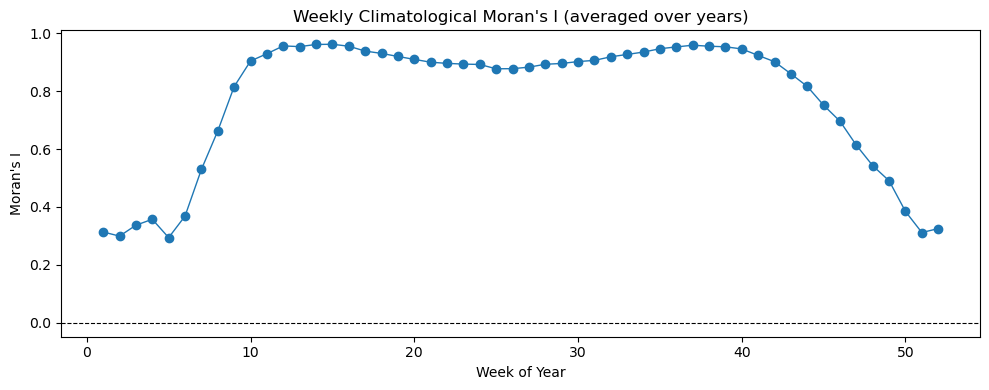

In [5]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import pyreadr
import matplotlib.pyplot as plt

# ================================================================
# 1. Load data (same cleaning as BYM)
# ================================================================
no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

snow = pyreadr.read_r("snow_cleaned_full.Rda")
snow = list(snow.values())[0]

all_y = snow.drop(index=no_nbs).reset_index(drop=True)

coords = all_y.iloc[:, :2].to_numpy()
y_raw  = all_y.iloc[:, 2:].to_numpy()   # (S, T)

S, T = y_raw.shape
assert T % 52 == 0, "Total time length must be multiple of 52"

n_years = T // 52
print(f"[INFO] S={S}, years={n_years}, weeks=52")

# ================================================================
# 2. Aggregate across YEARS for each WEEK
# ================================================================
# y_week[s, w] = average over years at week w
y_week = np.zeros((S, 52))

for w in range(52):
    cols = np.arange(w, T, 52)   # week w across all years
    y_week[:, w] = y_raw[:, cols].mean(axis=1)

# ================================================================
# 3. Build adjacency (same as BYM)
# ================================================================
gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords[:, 0], coords[:, 1]),
    crs="EPSG:4326"
)
gdf = gdf.to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")
xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6

D = squareform(pdist(xy))
A = (D <= 0.22).astype(int)
np.fill_diagonal(A, 0)
W = csr_matrix(A)

# keep largest connected component (match your model)
n_comp, labels = connected_components(W, directed=False)
largest = np.argmax(np.bincount(labels))
keep = np.where(labels == largest)[0]

W = W[keep][:, keep]
y_week = y_week[keep, :]
S = y_week.shape[0]

print(f"[INFO] Using largest component: S={S}")

# ================================================================
# 4. Moran's I
# ================================================================
def morans_I(x, W):
    x = x.astype(float)
    x_bar = x.mean()
    z = x - x_bar

    num = z @ (W @ z)
    den = z @ z
    W_sum = W.sum()

    if den == 0 or W_sum == 0:
        return np.nan

    return (len(x) / W_sum) * (num / den)

# ================================================================
# 5. Weekly Moran's I (seasonal)
# ================================================================
I_weekly = np.array([
    morans_I(y_week[:, w], W) for w in range(52)
])

# ================================================================
# 6. Save + plot
# ================================================================
df_I = pd.DataFrame({
    "week": np.arange(1, 53),
    "morans_I": I_weekly
})

df_I.to_csv("weekly_climatology_morans_I.csv", index=False)

plt.figure(figsize=(10, 4))
plt.plot(df_I["week"], df_I["morans_I"], marker="o", lw=1)
plt.axhline(0, color="k", ls="--", lw=0.8)
plt.xlabel("Week of Year")
plt.ylabel("Moran's I")
plt.title("Weekly Climatological Moran's I (averaged over years)")
plt.tight_layout()
plt.show()


Detected change points (weeks): [5, 10, 45]


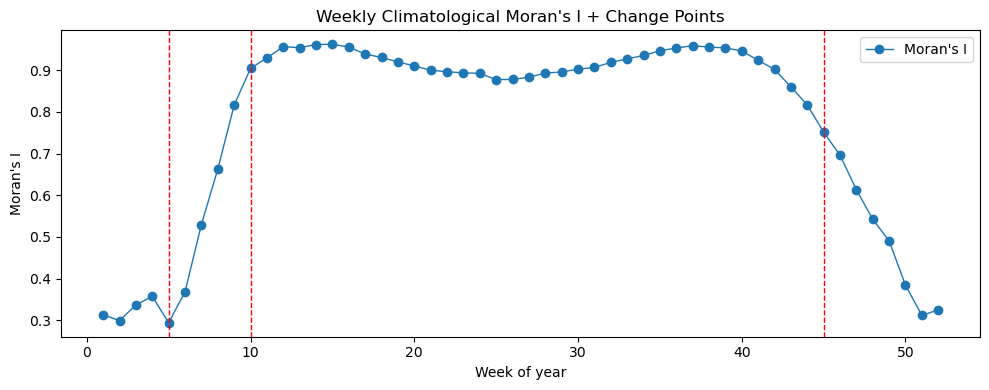

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt
I = I_weekly.copy()   # length 52
weeks = np.arange(1, 53)
I_std = (I - np.nanmean(I)) / np.nanstd(I)
model = rpt.Pelt(model="l2").fit(I_std)


pen = 5.0
cps = model.predict(pen=pen)

cps = [cp for cp in cps if cp < len(I)]
print("Detected change points (weeks):", cps)

plt.figure(figsize=(10,4))
plt.plot(weeks, I, marker="o", lw=1, label="Moran's I")

for cp in cps:
    plt.axvline(cp, color="red", ls="--", lw=1)

plt.xlabel("Week of year")
plt.ylabel("Moran's I")
plt.title("Weekly Climatological Moran's I + Change Points")
plt.legend()
plt.tight_layout()
plt.show()




01 change points (weeks): [5, 30, 40]
10 change points (weeks): [10, 50]


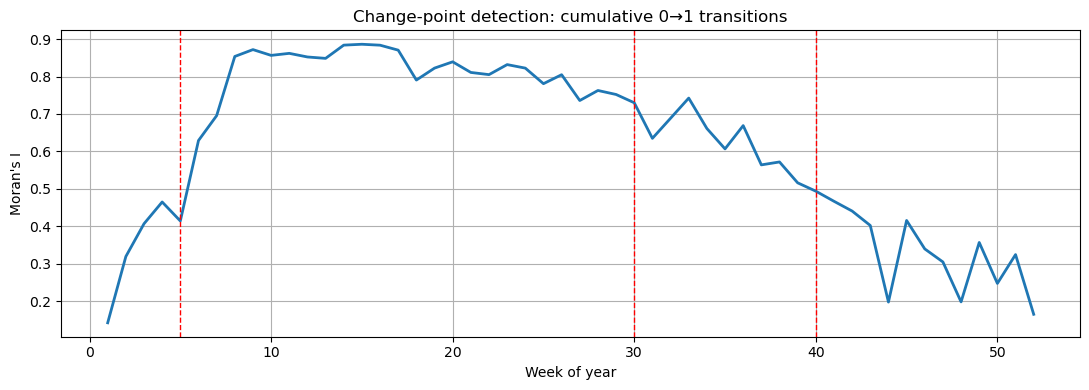

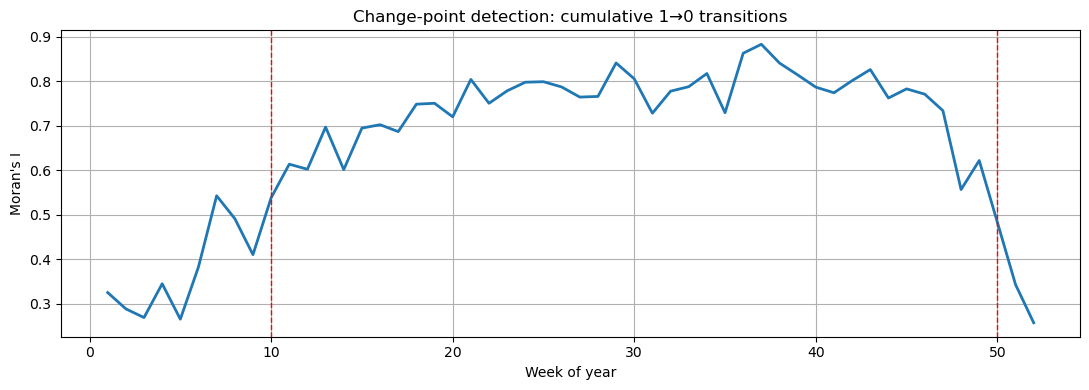

In [12]:
# ================================================================
# FULL PIPELINE:
# 1) cumulative weekly 0→1 / 1→0 transition counts
# 2) weekly Moran's I
# 3) multiple change-point detection (01 and 10 SEPARATELY)
# ================================================================

import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import pyreadr
import matplotlib.pyplot as plt
import ruptures as rpt

# ================================================================
# Load data (remove isolated points)
# ================================================================
no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

snow = pyreadr.read_r("snow_cleaned_full.Rda")
snow = list(snow.values())[0]

all_y = snow.drop(index=no_nbs).reset_index(drop=True)
coords_full = all_y.iloc[:, :2].to_numpy()
y_full      = all_y.iloc[:, 2:].to_numpy()   # (S_full, TT)

S_full, TT = y_full.shape
period = 52

# ================================================================
# Build adjacency on FULL graph
# ================================================================
gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_full[:, 0], coords_full[:, 1]),
    crs="EPSG:4326"
)
gdf = gdf.to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")
xy_full = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6

A_full = (squareform(pdist(xy_full)) <= 0.22).astype(int)
np.fill_diagonal(A_full, 0)
A_full = csr_matrix(A_full)

# ================================================================
# Merge two largest connected components (same as BYM)
# ================================================================
n_comp, labels = connected_components(A_full, directed=False)
sizes = np.bincount(labels)
comp1, comp2 = np.argsort(sizes)[-2:][::-1]

keep = np.where((labels == comp1) | (labels == comp2))[0]

coords = coords_full[keep]
xy     = xy_full[keep]
y      = y_full[keep]
S      = y.shape[0]

# ================================================================
# Rebuild adjacency (merged)
# ================================================================
A = (squareform(pdist(xy)) <= 0.22).astype(int)
np.fill_diagonal(A, 0)
A = csr_matrix(A)

# ================================================================
# Moran's I function
# ================================================================
def morans_I(x, W):
    x = x.astype(float)
    z = x - x.mean()
    den = np.sum(z**2)
    if den == 0:
        return np.nan
    W_sum = W.sum()
    if W_sum == 0:
        return np.nan
    num = z @ (W @ z)
    return (len(x) / W_sum) * (num / den)

# ================================================================
# Build cumulative weekly transition counts
# ================================================================
W = 52
C01 = np.zeros((S, W), dtype=int)
C10 = np.zeros((S, W), dtype=int)

for t in range(TT - 1):
    w = t % 52          # 0..51
    y_t  = y[:, t]
    y_t1 = y[:, t + 1]

    C01[:, w] += (y_t == 0) & (y_t1 == 1)
    C10[:, w] += (y_t == 1) & (y_t1 == 0)

# ================================================================
# Weekly Moran's I
# ================================================================
I01 = np.zeros(W)
I10 = np.zeros(W)

for w in range(W):
    I01[w] = morans_I(C01[:, w], A)
    I10[w] = morans_I(C10[:, w], A)

weeks = np.arange(1, 53)

# ================================================================
# Clean NaNs (safety)
# ================================================================
mask01 = ~np.isnan(I01)
mask10 = ~np.isnan(I10)

I01_c = I01[mask01]
weeks_01 = weeks[mask01]

I10_c = I10[mask10]
weeks_10 = weeks[mask10]

# ================================================================
# Change-point detection (PELT)
# ================================================================
def run_cpd(x, pen):
    algo = rpt.Pelt(model="l2").fit(x)
    bkps = algo.predict(pen=pen)
    return np.asarray(bkps[:-1], dtype=int)  # drop endpoint

pen_01 = 0.1
pen_10 = 0.1

cp_01 = run_cpd(I01_c, pen_01)
cp_10 = run_cpd(I10_c, pen_10)

# map CP indices → week-of-year
cp_01 = cp_01[(cp_01 > 0) & (cp_01 < len(weeks_01))]
cp_10 = cp_10[(cp_10 > 0) & (cp_10 < len(weeks_10))]

cp_weeks_01 = weeks_01[cp_01 - 1]
cp_weeks_10 = weeks_10[cp_10 - 1]

print("01 change points (weeks):", cp_weeks_01.tolist())
print("10 change points (weeks):", cp_weeks_10.tolist())

# ================================================================
# Plots
# ================================================================
plt.figure(figsize=(11, 4))
plt.plot(weeks_01, I01_c, lw=2, label="0→1")
for w in cp_weeks_01:
    plt.axvline(w, color="red", ls="--", lw=1)
plt.xlabel("Week of year")
plt.ylabel("Moran's I")
plt.title("Change-point detection: cumulative 0→1 transitions")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
plt.plot(weeks_10, I10_c, lw=2, label="1→0")
for w in cp_weeks_10:
    plt.axvline(w, color="red", ls="--", lw=1)
plt.xlabel("Week of year")
plt.ylabel("Moran's I")
plt.title("Change-point detection: cumulative 1→0 transitions")
plt.grid(True)
plt.tight_layout()
plt.show()

